# Predikcija cene polovnih automobila

**Autor:** Stefan Stojanović

## Cilj projekta

Cilj ovog projekta je razvoj regresionog modela koji predviđa cenu polovnog automobila izraženu u američkim dolarima (`priceUSD`) na osnovu njegovih karakteristika.

Projekat obuhvata kompletan tok razvoja rešenja mašinskog učenja:

1. istraživačku analizu podataka (EDA);
2. čišćenje podataka;
3. inženjering karakteristika;
4. pretprocesiranje numeričkih i kategorijskih podataka;
5. treniranje i poređenje više regresionih modela;
6. evaluaciju i izbor najboljeg modela;
7. čuvanje finalnog modela za buduća predviđanja.

Posebna pažnja biće posvećena metrici **MAE (Mean Absolute Error)**, jer ona pokazuje za koliko dolara model u proseku odstupa od stvarne cene automobila.

## 1. Uvoz potrebnih biblioteka

U ovom koraku učitavamo biblioteke koje ćemo koristiti za obradu i analizu podataka, izradu grafikona, pretprocesiranje, treniranje regresionih modela i njihovu evaluaciju.

In [1]:
# Biblioteke za rad sa podacima
import pandas as pd
import numpy as np

# Biblioteke za vizualizaciju
import matplotlib.pyplot as plt
import seaborn as sns

# Prikaz svih kolona u Pandas tabelama
pd.set_option("display.max_columns", None)

# Podešavanje izgleda grafikona
sns.set_theme(style="whitegrid")

print("Biblioteke su uspešno učitane.")

Biblioteke su uspešno učitane.


## 2. Učitavanje skupa podataka

Skup podataka `cars.csv` nalazi se u folderu `data`. Nakon učitavanja proveravamo njegove dimenzije i prikazujemo prvih pet redova kako bismo se upoznali sa strukturom podataka.

In [2]:
from pathlib import Path

# Putanja prilagođena pokretanju sveske iz različitih radnih direktorijuma
data_path = Path("../data/cars.csv")

if not data_path.exists():
    data_path = Path("data/cars.csv")

# Učitavanje podataka
df = pd.read_csv(data_path)

print(f"Skup podataka sadrži {df.shape[0]} redova i {df.shape[1]} kolona.")

df.head()

Skup podataka sadrži 56244 redova i 12 kolona.


,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,B
1,mazda,2,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,B
2,mazda,2,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,B
3,mazda,2,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,B
4,mazda,2,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,B


## 3. Početno istraživanje podataka (EDA)

Najpre proveravamo dimenzije skupa, nazive kolona, tipove podataka i broj popunjenih vrednosti. Ova analiza pomaže da identifikujemo kolone koje zahtevaju čišćenje ili promenu tipa podataka.

In [3]:
print("DIMENZIJE SKUPA PODATAKA")
print(f"Broj redova: {df.shape[0]}")
print(f"Broj kolona: {df.shape[1]}")

print("\nNAZIVI KOLONA")
for column in df.columns:
    print(f"- {column}")

print("\nOSNOVNE INFORMACIJE O PODACIMA")
df.info()

DIMENZIJE SKUPA PODATAKA
Broj redova: 56244
Broj kolona: 12

NAZIVI KOLONA
- make
- model
- priceUSD
- year
- condition
- mileage(kilometers)
- fuel_type
- volume(cm3)
- color
- transmission
- drive_unit
- segment

OSNOVNE INFORMACIJE O PODACIMA
<class 'pandas.DataFrame'>
RangeIndex: 56244 entries, 0 to 56243
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make                 56244 non-null  str    
 1   model                56244 non-null  str    
 2   priceUSD             56244 non-null  int64  
 3   year                 56244 non-null  int64  
 4   condition            56244 non-null  str    
 5   mileage(kilometers)  56244 non-null  float64
 6   fuel_type            56244 non-null  str    
 7   volume(cm3)          56197 non-null  float64
 8   color                56244 non-null  str    
 9   transmission         56244 non-null  str    
 10  drive_unit           54339 non-null  str    
 11  s

### 3.1. Nedostajuće vrednosti i duplirani redovi

Proveravamo broj i procenat nedostajućih vrednosti po kolonama, kao i broj potpuno dupliranih redova. Ovi rezultati će nam pomoći da kasnije donesemo odgovarajuće odluke tokom čišćenja podataka.

In [4]:
# Broj i procenat nedostajućih vrednosti po kolonama
missing_values = pd.DataFrame({
    "broj_nedostajucih": df.isna().sum(),
    "procenat_nedostajucih": (df.isna().mean() * 100).round(2)
})

missing_values = missing_values[
    missing_values["broj_nedostajucih"] > 0
].sort_values("broj_nedostajucih", ascending=False)

print("NEDOSTAJUĆE VREDNOSTI")
display(missing_values)

# Provera potpuno dupliranih redova
duplicate_count = df.duplicated().sum()

print(f"\nBroj potpuno dupliranih redova: {duplicate_count}")
print(f"Procenat dupliranih redova: {duplicate_count / len(df) * 100:.2f}%")

NEDOSTAJUĆE VREDNOSTI


,broj_nedostajucih,procenat_nedostajucih
segment,5291,9.41
drive_unit,1905,3.39
volume(cm3),47,0.08



Broj potpuno dupliranih redova: 87
Procenat dupliranih redova: 0.15%


**Zaključak:** Nedostajuće vrednosti postoje samo u kolonama `segment`, `drive_unit` i `volume(cm3)`. Najveći udeo nedostajućih podataka ima kolona `segment` (9,41%), pa njeno potpuno uklanjanje ne bi bilo opravdano. Kategorijske vrednosti biće kasnije popunjene pomoću najčešće kategorije, dok će numerička kolona `volume(cm3)` biti popunjena medijanom u okviru preprocessing pipeline-a. Pronađeno je i 87 potpuno dupliranih redova, koji će biti uklonjeni tokom čišćenja podataka.

### 3.2. Osnovna statistika numeričkih kolona

Analiziramo raspodelu numeričkih kolona kako bismo uočili neuobičajeno male ili velike vrednosti cene, godišta, kilometraže i zapremine motora.

In [5]:
numeric_summary = df.select_dtypes(include=np.number).describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
priceUSD,56244.0,7415.456440,8316.959261,48.0,2350.0,5350.0,9807.5,235235.0
year,56244.0,2003.454840,8.144247,1910.0,1998.0,2004.0,2010.0,2019.0
mileage(kilometers),56244.0,244395.631020,321030.668382,0.0,137000.0,228500.0,310000.0,9999999.0
volume(cm3),56197.0,2104.860615,959.201633,500.0,1600.0,1996.0,2300.0,20000.0


**Zaključak:** Numeričke kolone sadrže potencijalno ekstremne vrednosti. Ciljna promenljiva `priceUSD` ima prosek veći od medijane, što ukazuje na raspodelu nagnutu udesno zbog manjeg broja veoma skupih automobila. Posebno treba proveriti minimalnu cenu od 48 USD, godište 1910, kilometražu od 9.999.999 km i zapreminu motora od 20.000 cm³. Granice za čišćenje nećemo postaviti samo na osnovu minimuma i maksimuma, već ćemo prvo analizirati percentile i raspodelu podataka.

### 3.3. Analiza percentila i potencijalnih ekstremnih vrednosti

Percentili omogućavaju da utvrdimo koliko su najekstremnije vrednosti udaljene od najvećeg dela skupa podataka i pomažu pri izboru razumnih pravila za čišćenje.

In [6]:
percentiles = df[
    ["priceUSD", "year", "mileage(kilometers)", "volume(cm3)"]
].quantile([0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.999]).T

percentiles.columns = [
    "0.1%", "1%", "5%", "50%", "95%", "99%", "99.9%"
]

percentiles

,0.1%,1%,5%,50%,95%,99%,99.9%
priceUSD,166.486,333.0,700.00,5350.0,20000.0,39728.5,86975.700
year,1961.243,1984.0,1990.00,2004.0,2016.0,2018.0,2019.000
mileage(kilometers),0.000,15.0,2730.75,228500.0,431000.0,630000.0,4444504.046
volume(cm3),800.000,1000.0,1300.00,1996.0,3500.0,5000.0,18000.000


**Zaključak:** Percentili potvrđuju prisustvo malog broja veoma ekstremnih vrednosti. Posebno se izdvajaju kilometraža i zapremina motora, kod kojih se između 99. i 99,9. percentila javlja veliki skok. Ove vrednosti mogu predstavljati greške pri unosu i mogle bi značajno uticati na regresione modele. Pre njihovog uklanjanja biće dodatno provereni broj takvih redova i konkretni primeri.

### 3.4. Raspodela ciljne promenljive `priceUSD`

Analiziramo raspodelu cena na originalnoj i logaritamskoj skali. Prvi grafikon prikazuje najveći deo podataka do 99. percentila, dok logaritamska transformacija omogućava jasniji pregled cele raspodele, uključujući veoma skupe automobile.

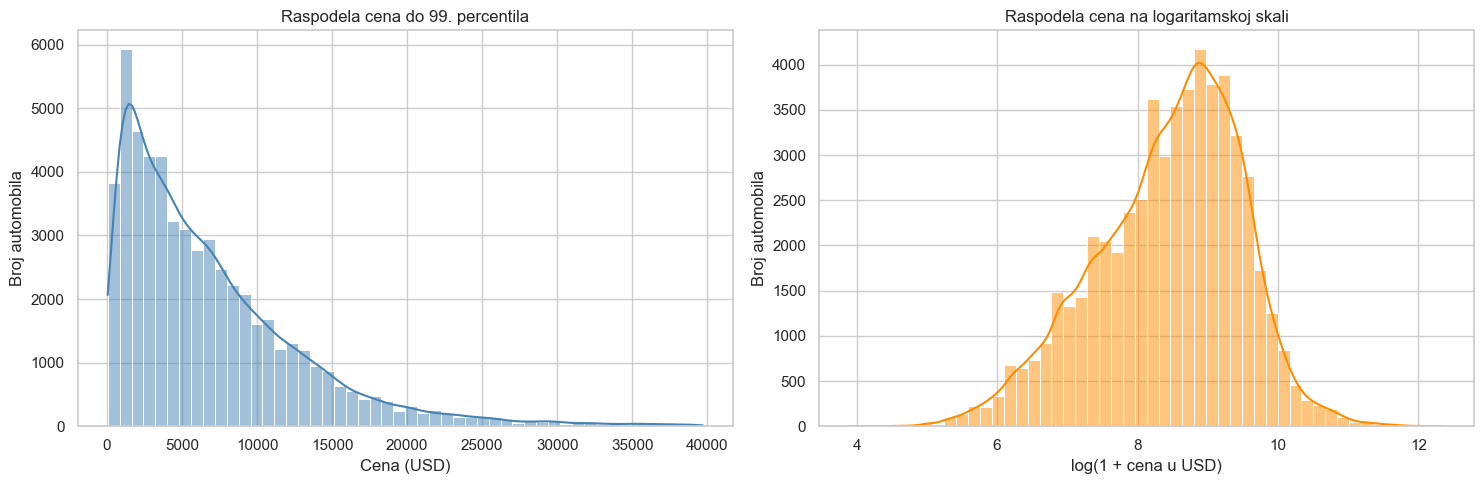

In [7]:
price_99th_percentile = df["priceUSD"].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Raspodela najvećeg dela cena
sns.histplot(
    data=df[df["priceUSD"] <= price_99th_percentile],
    x="priceUSD",
    bins=50,
    kde=True,
    color="steelblue",
    ax=axes[0]
)
axes[0].set_title("Raspodela cena do 99. percentila")
axes[0].set_xlabel("Cena (USD)")
axes[0].set_ylabel("Broj automobila")

# Cela raspodela na logaritamskoj skali
sns.histplot(
    np.log1p(df["priceUSD"]),
    bins=50,
    kde=True,
    color="darkorange",
    ax=axes[1]
)
axes[1].set_title("Raspodela cena na logaritamskoj skali")
axes[1].set_xlabel("log(1 + cena u USD)")
axes[1].set_ylabel("Broj automobila")

plt.tight_layout()
plt.show()

**Zaključak:** Raspodela ciljne promenljive izrazito je nagnuta udesno. Većina automobila ima nižu ili srednju cenu, dok mali broj veoma skupih vozila formira dugačak desni rep. Logaritamska skala daje uravnoteženiji prikaz raspodele. Ovu osobinu treba uzeti u obzir pri poređenju modela, jer ekstremno visoke cene mogu snažnije uticati na metrike poput MSE i RMSE.

### 3.5. Broj potencijalno ekstremnih zapisa

Koristimo privremene granice samo za dijagnostiku. Njihova svrha je da pokažu koliko bi redova bilo obuhvaćeno određenim pravilima, pre nego što donesemo konačnu odluku o čišćenju.

In [8]:
extreme_summary = pd.DataFrame({
    "uslov": [
        "priceUSD < 200",
        "priceUSD > 100000",
        "year < 1960",
        "mileage(kilometers) > 1000000",
        "volume(cm3) > 8000"
    ],
    "broj_redova": [
        (df["priceUSD"] < 200).sum(),
        (df["priceUSD"] > 100000).sum(),
        (df["year"] < 1960).sum(),
        (df["mileage(kilometers)"] > 1_000_000).sum(),
        (df["volume(cm3)"] > 8_000).sum()
    ]
})

extreme_summary["procenat_skupa"] = (
    extreme_summary["broj_redova"] / len(df) * 100
).round(3)

extreme_summary

,uslov,broj_redova,procenat_skupa
0,priceUSD < 200,78,0.139
1,priceUSD > 100000,33,0.059
2,year < 1960,44,0.078
3,mileage(kilometers) > 1000000,364,0.647
4,volume(cm3) > 8000,88,0.156


**Zaključak:** Potencijalno ekstremni zapisi čine mali procenat skupa. Najviše ih je u kilometraži preko milion kilometara (0,647%). Međutim, sama ekstremna vrednost nije dovoljan razlog za uklanjanje reda. Veoma skupi i stari automobili mogu biti validni, dok neuobičajene kilometraže i zapremine motora češće mogu ukazivati na greške pri unosu. Zbog toga će konkretni primeri biti pregledani pre definisanja pravila čišćenja.

### 3.6. Pregled automobila sa ekstremnim cenama

Pregledamo oglase sa najnižim i najvišim cenama zajedno sa njihovim osnovnim karakteristikama. Cilj je da utvrdimo da li ekstremne cene predstavljaju greške ili se mogu objasniti stanjem, markom, modelom i godištem automobila.

In [9]:
columns_to_show = [
    "make",
    "model",
    "priceUSD",
    "year",
    "condition",
    "mileage(kilometers)",
    "fuel_type",
    "volume(cm3)",
    "segment"
]

print("DESET AUTOMOBILA SA NAJNIŽOM CENOM")
display(
    df.nsmallest(10, "priceUSD")[columns_to_show]
)

print("\nDESET AUTOMOBILA SA NAJVIŠOM CENOM")
display(
    df.nlargest(10, "priceUSD")[columns_to_show]
)

DESET AUTOMOBILA SA NAJNIŽOM CENOM


,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),segment
5952,zaz,968,48,1910,with damage,25000.0,petrol,1100.0,B
40252,proton,persona,95,1997,with damage,1111.0,petrol,1600.0,NaN
5456,mazda,626,100,1986,with mileage,100.0,petrol,2000.0,C
7314,mercedes-benz,190-w201,100,1991,for parts,2000.0,petrol,2000.0,D
20971,toyota,corolla,100,1988,for parts,300000.0,petrol,1300.0,C
23898,ford,escort,100,1986,for parts,200000.0,petrol,1300.0,C
24873,ford,fiesta,100,1992,for parts,1.0,petrol,1100.0,B
41010,nissan,primera,100,1994,for parts,300000.0,petrol,2000.0,D
54171,citroen,xantia,100,1995,for parts,380000.0,petrol,1800.0,D
7076,lada-vaz,21099,119,1992,for parts,20000.0,petrol,1500.0,B



DESET AUTOMOBILA SA NAJVIŠOM CENOM


,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),segment
20787,bentley,continental-gt,235235,2018,with mileage,29000.0,petrol,6000.0,NaN
16430,bentley,bentayga,195000,2016,with mileage,72000.0,petrol,6000.0,NaN
35457,bentley,mulsanne,190141,2014,with mileage,36500.0,petrol,6750.0,NaN
16428,bentley,bentayga,183848,2016,with mileage,22000.0,petrol,6000.0,NaN
16429,bentley,bentayga,170477,2016,with mileage,74100.0,petrol,6000.0,NaN
19557,porsche,cayenne,170000,2018,with mileage,1020.0,petrol,4000.0,J
34508,tesla,model-x,161563,2019,with mileage,50.0,electrocar,NaN,NaN
26254,mercedes-benz,g-klass,150000,2001,with mileage,160000.0,petrol,5000.0,J
33702,mercedes-benz,maybach,148000,2019,with mileage,950.0,petrol,3000.0,NaN
33327,bmw,m5,128136,2019,with mileage,2925.0,petrol,4400.0,NaN


**Zaključak:** Većina najjeftinijih automobila označena je kao oštećena ili namenjena za delove, pa njihove niske cene mogu biti realne. Najskuplji oglasi uglavnom predstavljaju novije luksuzne automobile marki Bentley, Porsche, Tesla, Mercedes-Benz i BMW, zbog čega ni visoke cene nisu nužno greške. Zato automobile nećemo uklanjati samo na osnovu cene. Druge sumnjive podatke, poput godišta 1910. za model ZAZ 968, proverićemo prilikom analize godišta.

### 3.7. Pregled ekstremne kilometraže i zapremine motora

Pregledamo automobile sa najvećom kilometražom i zapreminom motora kako bismo utvrdili da li su te vrednosti realne ili predstavljaju greške pri unosu.

In [10]:
print("DESET AUTOMOBILA SA NAJVEĆOM KILOMETRAŽOM")
display(
    df.nlargest(10, "mileage(kilometers)")[columns_to_show]
)

print("\nDESET AUTOMOBILA SA NAJVEĆOM ZAPREMINOM MOTORA")
display(
    df.nlargest(10, "volume(cm3)")[columns_to_show]
)

DESET AUTOMOBILA SA NAJVEĆOM KILOMETRAŽOM


,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),segment
1394,audi,80,500,1986,with mileage,9999999.0,petrol,1800.0,D
1854,audi,100,900,1989,with mileage,9999999.0,petrol,2300.0,E
5783,peugeot,806,4100,2000,with mileage,9999999.0,diesel,2000.0,M
6114,lada-vaz,2104,600,1990,with mileage,9999999.0,petrol,1500.0,B
6465,lada-vaz,2108,295,1990,with mileage,9999999.0,petrol,1100.0,B
6684,raf,2203,1000,1991,with mileage,9999999.0,petrol,2400.0,NaN
10032,bmw,5-seriya,2000,1985,with mileage,9999999.0,petrol,2800.0,E
10316,bmw,7-seriya,4650,1998,with mileage,9999999.0,petrol,3000.0,F
11699,audi,a4,3000,1996,with mileage,9999999.0,petrol,1800.0,D
16705,fiat,brava,1100,1997,with mileage,9999999.0,petrol,1400.0,C



DESET AUTOMOBILA SA NAJVEĆOM ZAPREMINOM MOTORA


,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),segment
81,mazda,3,5300,2006,with mileage,168000.0,petrol,20000.0,C
354,mazda,6,7500,2003,with mileage,240000.0,diesel,20000.0,D
1537,audi,80,2900,1993,with mileage,392432.0,petrol,20000.0,D
1768,audi,100,2150,1992,with mileage,300000.0,petrol,20000.0,E
4573,peugeot,407,4600,2004,with mileage,262900.0,petrol,20000.0,D
4816,volvo,460,750,1994,with mileage,333000.0,petrol,20000.0,C
5369,mazda,626,1200,1995,with mileage,425326.0,petrol,20000.0,C
5553,mazda,626,1000,1990,with mileage,250000.0,petrol,20000.0,C
5607,mazda,626,1200,1989,with mileage,0.0,petrol,20000.0,C
5908,volvo,940,1521,1997,with mileage,300000.0,petrol,20000.0,E


**Zaključak:** Vrednost kilometraže od 9.999.999 km ponavlja se kod različitih marki i modela i predstavlja očiglednu zamensku ili pogrešno unetu vrednost. Takođe, zapremine motora od 20.000 cm³ nisu realne za prikazane putničke automobile i verovatno su posledica pogrešnog unosa dodatne nule. Da ne bismo izmišljali stvarne vrednosti, kilometraže veće od 1.000.000 km i zapremine veće od 8.000 cm³ biće označene kao nedostajuće, a zatim obrađene imputacijom.

### 3.8. Pregled najstarijih automobila

Veoma stari automobili mogu biti validni kolekcionarski primerci, ali mogu sadržati i pogrešno uneto godište. Pregled marke i modela pomaže da razlikujemo realne stare automobile od očiglednih grešaka.

In [11]:
print("PETNAEST AUTOMOBILA SA NAJSTARIJIM GODIŠTEM")

display(
    df.nsmallest(15, "year")[columns_to_show]
)

PETNAEST AUTOMOBILA SA NAJSTARIJIM GODIŠTEM


,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),segment
5952,zaz,968,48,1910,with damage,25000.0,petrol,1100.0,B
43024,eksklyuziv,retro,50000,1933,with mileage,1.0,petrol,2400.0,NaN
43020,eksklyuziv,retro,4991,1936,with damage,175000.0,petrol,1800.0,NaN
43025,eksklyuziv,retro,12500,1938,with mileage,100000.0,petrol,3000.0,NaN
42986,eksklyuziv,redkaya-model,17000,1942,with mileage,40000.0,petrol,2000.0,NaN
52637,eksklyuziv,voennaya-tehnika,20000,1945,with mileage,1.0,petrol,2199.0,NaN
1048,gaz,67,9200,1948,with mileage,100000.0,petrol,3200.0,NaN
33000,gaz,m-20-pobeda,2800,1949,with mileage,55555.0,petrol,2400.0,NaN
32995,gaz,m-20-pobeda,2000,1950,with mileage,100000.0,petrol,2400.0,NaN
32998,gaz,m-20-pobeda,5900,1950,with mileage,1111.0,petrol,2200.0,NaN


**Zaključak:** Najstarije godište u skupu je 1910, dok je sledeće najstarije 1933. Zbog velikog odstupanja, vrednost 1910. posmatramo kao potencijalnu grešku. Tokom čišćenja uklonićemo samo redove sa godištem pre 1930.

### 3.9. Pregled kategorijskih kolona

Analiziramo broj jedinstvenih vrednosti, nedostajuće podatke i najčešću kategoriju u svakoj tekstualnoj koloni. Posebno je važan broj kategorija jer veliki broj različitih vrednosti može povećati složenost One-Hot Encoding-a i modela.

In [13]:
# Kategorijske kolone u skupu podataka
categorical_columns = [
    "make",
    "model",
    "condition",
    "fuel_type",
    "color",
    "transmission",
    "drive_unit",
    "segment"
]

# Osnovni pregled kategorijskih kolona
categorical_summary = pd.DataFrame({
    "broj_jedinstvenih": df[categorical_columns].nunique(),
    "broj_nedostajucih": df[categorical_columns].isna().sum()
})

categorical_summary

,broj_jedinstvenih,broj_nedostajucih
make,96,0
model,1034,0
condition,3,0
fuel_type,3,0
color,13,0
transmission,2,0
drive_unit,4,1905
segment,9,5291


**Zaključak:** Kolona `model` ima najveći broj različitih vrednosti (1.034), dok `make` ima 96. Nedostajuće vrednosti postoje samo u kolonama `drive_unit` i `segment`. Kategorijske kolone biće pripremljene pomoću imputacije i One-Hot Encoding-a.